# Quiz 4

<font size='4'>

BIOS-584<br>
Date: Nov 21, 2025<br>
Name: Madelyn Carlson

In [71]:
import numpy as np
import os
import pandas as pd
from matplotlib import pyplot as plt

## Preliminary

<font size='4'>
    
* There are six files stored under `Your own GitHub repository/data/Quiz4`.
* Import those six files using relevant functions in `Pandas`.

In [76]:
path = "/Users/madelyncarlson/Documents/GitHub/BIOS-584/data/Quiz4/"
data_1 = pd.read_csv(path + "data_1.txt", sep=",")
data_2 = pd.read_csv(path + "data_2.txt", sep=",")
data_3 = pd.read_csv(path + "data_3.txt", sep=",")
data_4 = pd.read_csv(path + "data_4.txt", sep=",")
data_5 = pd.read_csv(path + "data_5.txt", sep=",")
data_6 = pd.read_csv(path + "data_6.txt", sep=",")

## Import Data

<font size='4'>

* Three lists named `study_id_ls`, `measure_date_ls`, and `duration_ls` have been initialized.
* Write a for loop to extract and append the values of `study_id`, `measure_date`, and `duration` to `study_id_ls`, `measure_date_ls`, and `duration_ls`, respectively.

In [77]:
study_id_ls = []
measure_date_ls = []
duration_ls = []

combined_data = pd.concat([data_1, data_2, data_3, data_4, data_5, data_6], ignore_index=True)

for idx, row in combined_data.iterrows():
    study_id_ls.append(row['study_id'])
    measure_date_ls.append(row['measure_date'])
    duration_ls.append(row['duration'])

<font size='4'>

* Create a new Pandas Dataframe combining three lists and name it `input_df`.

In [78]:
input_df = pd.DataFrame({
    'study_id': study_id_ls,
    'measure_date': measure_date_ls,
    'duration': duration_ls
})

<font size='4'>

* Visualize `input_df`

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   study_id      6 non-null      int64 
 1   measure_date  6 non-null      object
 2   duration      6 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 276.0+ bytes
None

   study_id measure_date  duration
0         1   2025-01-01       100
1         1   2025-03-01       300
2         1   2025-02-01       200
3         1   2025-11-01        25
4         1   2025-11-01        20
5         1   2025-11-03        30


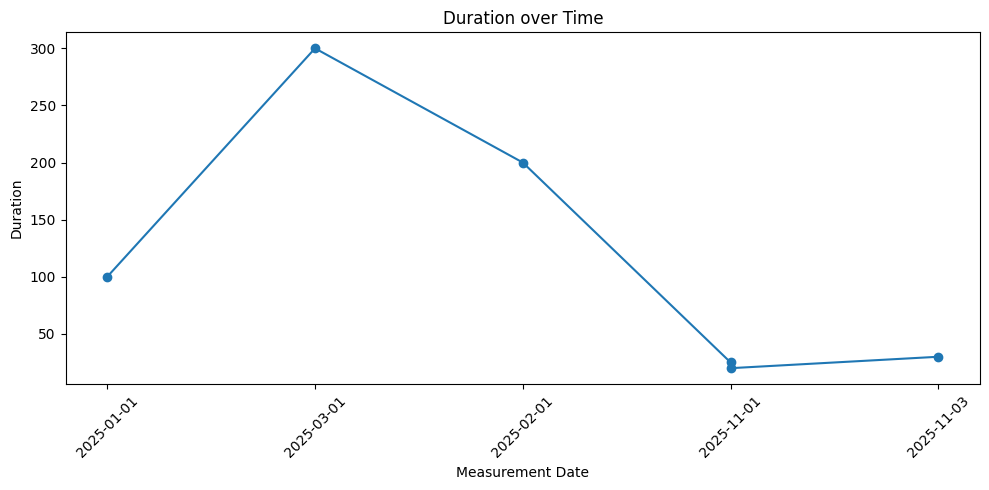

In [79]:
print(input_df.info())
print()
print(input_df)
# Print the data using a line plot. I selected a line plot bc these are often used for showing how duration changes over time (source: https://www.aicg.com/blog/how-to-visualize-time-series-data-with-examples)
plt.figure(figsize=(10,5))
plt.plot(input_df['measure_date'], input_df['duration'], marker='o', linestyle='-')
plt.title('Duration over Time')
plt.xlabel('Measurement Date')
plt.ylabel('Duration')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Data Manipulation

<font size='4'>

* Reorder the dataframe by `measure_date` (earliest to latest) and then by `duration` (shortest to longest).

In [80]:
input_df_sorted = input_df.sort_values(by=['measure_date', 'duration'], ascending=[True, True])
print(input_df_sorted.head(6))

   study_id measure_date  duration
0         1   2025-01-01       100
2         1   2025-02-01       200
1         1   2025-03-01       300
4         1   2025-11-01        20
3         1   2025-11-01        25
5         1   2025-11-03        30


<font size='4'>

* Create a new column called `relative_time` by calculating the time difference in days between each of the measure date and the earliest one.

In [84]:
input_df['measure_date'] = pd.to_datetime(input_df['measure_date'], errors='coerce') # I was getting an error "TypeError: unsupported operand type(s) for -: 'str' and 'str'" so I added this code
earliest_date = input_df['measure_date'].min()
input_df['relative_time'] = (input_df['measure_date'] - earliest_date).dt.days
print(input_df.head())

   study_id measure_date  duration  relative_time
0         1   2025-01-01       100              0
1         1   2025-03-01       300             59
2         1   2025-02-01       200             31
3         1   2025-11-01        25            304
4         1   2025-11-01        20            304


<font size='4'>

* Reset the index column and remove the old index.

In [85]:
input_df = input_df.reset_index(drop=True)
print(input_df.head(6))

   study_id measure_date  duration  relative_time
0         1   2025-01-01       100              0
1         1   2025-03-01       300             59
2         1   2025-02-01       200             31
3         1   2025-11-01        25            304
4         1   2025-11-01        20            304
5         1   2025-11-03        30            306


## Final Data Visualization
<font size='4'>
    
* Display the final `input_df`.

In [88]:
print(input_df.info())
print()
# scroll down to see the full dataset printed 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   study_id       6 non-null      int64         
 1   measure_date   6 non-null      datetime64[ns]
 2   duration       6 non-null      int64         
 3   relative_time  6 non-null      int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 324.0 bytes
None

   study_id measure_date  duration  relative_time
0         1   2025-01-01       100              0
1         1   2025-03-01       300             59
2         1   2025-02-01       200             31
3         1   2025-11-01        25            304
4         1   2025-11-01        20            304
5         1   2025-11-03        30            306



In [89]:
print(input_df)
print()

   study_id measure_date  duration  relative_time
0         1   2025-01-01       100              0
1         1   2025-03-01       300             59
2         1   2025-02-01       200             31
3         1   2025-11-01        25            304
4         1   2025-11-01        20            304
5         1   2025-11-03        30            306

